# Notebook 2.0 — Modelação e Treino
## Projeto: Churn Prediction | ISCAC 2025/2026
**Fase CRISP-DM:** Modelling & Evaluation (M3)

| | |
|---|---|
| **Dataset** | Telco Customer Churn (~7043 registos) |
| **Target** | `Churn` — 0: Não-churn / 1: Churn |
| **Desequilíbrio** | ~73.5% Não-churn / ~26.5% Churn |
| **Objetivo SMART** | F1-Score ≥ 0.80 na classe Churn |

---

In [1]:
# ── Importações ───────────────────────────────────────────────
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      roc_auc_score, roc_curve, f1_score)
from imblearn.over_sampling   import SMOTE

# Estilo global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (10, 5), 'font.size': 11})

# Pasta de figuras
os.makedirs('reports/figures', exist_ok=True)

print('✅ Bibliotecas carregadas.')
print(f'   pandas {pd.__version__} | sklearn OK | imblearn OK')

✅ Bibliotecas carregadas.
   pandas 2.3.3 | sklearn OK | imblearn OK


---
## Aula 15 — 25/03/2026
### Metodologia de Avaliação e Partição de Dados

In [2]:
# ── Carregamento do Dataset ───────────────────────────────────
# Auto-deteta o CSV no Kaggle; cai para caminho local se necessário
matches = glob.glob('/kaggle/input/**/*.csv', recursive=True)

if matches:
    df = pd.read_csv(matches[0])
    print(f'Kaggle: {matches[0]}')
else:
    df = pd.read_csv('data/processed/churn_dataset_processed.csv')
    print('Local: data/processed/churn_dataset_processed.csv')

print(f'\nShape : {df.shape}')
print(f'Nulos : {df.isnull().sum().sum()}')
print(f'\nDistribuição do target:')
print(df['Churn'].value_counts(normalize=True).rename({0: 'Não-churn', 1: 'Churn'}).map('{:.1%}'.format))
df.head(3)

Kaggle: /kaggle/input/datasets/joscabeas/telco-churn-processed/telco_churn_processed (1).csv

Shape : (7043, 24)
Nulos : 0

Distribuição do target:
Churn
Não-churn    73.5%
Churn        26.5%
Name: proportion, dtype: object


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,TenureCohort,TotalServices,LTV_Estatico,ChargesPerService,RiskScore
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,0,Early,1,29.85,14.92,5
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,0,Mature,3,1936.30,14.24,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,1,Early,3,107.70,13.46,5


In [3]:
# ── Encoding das Variáveis Categóricas ───────────────────────
# SMOTE e sklearn requerem colunas numéricas
df_enc = df.copy()

# Binárias Yes/No → 0/1
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    df_enc[col] = df_enc[col].map({'Yes': 1, 'No': 0})

# gender
df_enc['gender'] = df_enc['gender'].map({'Male': 1, 'Female': 0})

# Nominais com 3+ categorias
cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaymentMethod', 'TenureCohort']
df_enc = pd.get_dummies(df_enc, columns=cat_cols, drop_first=True)

# Verificação
assert df_enc.select_dtypes('object').empty,  '❌ Colunas string em df_enc'
assert df_enc.isnull().sum().sum() == 0,      '❌ Nulos em df_enc'

print(f'✅ Encoding concluído: {df_enc.shape[1]} colunas numéricas')

✅ Encoding concluído: 37 colunas numéricas


In [4]:
# ── Separação X/y e Divisão Treino/Teste 80/20 ───────────────
X = df_enc.drop('Churn', axis=1)
y = df_enc['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Partição       | Registos | Churn')
print('-' * 40)
print(f'Treino (80%)   | {len(X_train):>8} | {y_train.mean():.1%}')
print(f'Teste  (20%)   | {len(X_test):>8} | {y_test.mean():.1%}')

Partição       | Registos | Churn
----------------------------------------
Treino (80%)   |     5634 | 26.5%
Teste  (20%)   |     1409 | 26.5%


### Justificação: Divisão 80/20 e SMOTE

**Divisão 80/20 estratificada**
- `test_size=0.2` → ~1409 registos no teste; suficiente para avaliação estatisticamente robusta.
- `stratify=y` → preserva a proporção real de churn (~26.5%) em ambas as partições, evitando enviesamento por acaso.
- `random_state=42` → reprodutibilidade total entre execuções e membros do grupo.

**SMOTE — apenas no treino**
Com ~73.5% de Não-churn, um modelo sem correcção tende a ignorar a classe minoritária.
O SMOTE (*Synthetic Minority Oversampling Technique*) gera exemplos sintéticos da classe minoritária no espaço de features, equilibrando o treino sem distorcer o teste.

> ⚠️ Aplicar SMOTE ao teste constituiria **data leakage** — avaliação com dados artificiais, métricas inflacionadas.

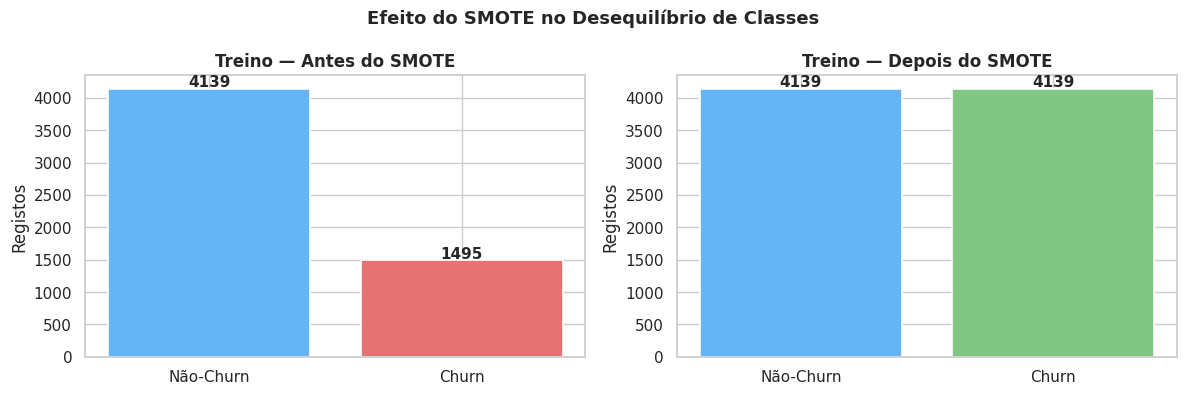

Treino balanceado: 8278 registos (4139 + 4139)
Teste (inalterado): 1409 registos | 26.5% churn


In [5]:
# ── SMOTE — apenas no treino ──────────────────────────────────
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Gráfico antes vs depois
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, title, cor_min in zip(
    axes,
    [y_train.value_counts().sort_index(), y_train_bal.value_counts().sort_index()],
    ['Antes do SMOTE', 'Depois do SMOTE'],
    ['#e57373', '#81c784']
):
    bars = ax.bar(['Não-Churn', 'Churn'], counts.values,
                  color=['#64b5f6', cor_min], edgecolor='white', linewidth=1.2)
    ax.set_title(f'Treino — {title}', fontweight='bold')
    ax.set_ylabel('Registos')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 30, str(v), ha='center', fontweight='bold')

plt.suptitle('Efeito do SMOTE no Desequilíbrio de Classes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/smote_balanceamento.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Treino balanceado: {X_train_bal.shape[0]} registos ({y_train_bal.value_counts()[0]} + {y_train_bal.value_counts()[1]})')
print(f'Teste (inalterado): {X_test.shape[0]} registos | {y_test.mean():.1%} churn')

In [6]:
# ── Escalonamento de Atributos (StandardScaler) ───────────────
# Fit apenas no treino (X_train_bal pós-SMOTE) → aplicar a treino e teste
# Necessário para LR (baseline) e KNN; modelos tree-based são invariantes à escala

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train_bal),
    columns=X_train_bal.columns
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print('✅ Escalonamento aplicado (StandardScaler fit no treino):')
print(f'   X_train_sc : {X_train_sc.shape}  |  μ≈{X_train_sc.mean().mean():.4f}  σ≈{X_train_sc.std().mean():.4f}')
print(f'   X_test_sc  : {X_test_sc.shape}')
print()
print('   LR e KNN beneficiam da normalização.')
print('   RF, GB, XGBoost e Decision Tree são invariantes à escala.')

✅ Escalonamento aplicado (StandardScaler fit no treino):
   X_train_sc : (8278, 36)  |  μ≈0.0000  σ≈1.0001
   X_test_sc  : (1409, 36)

   LR e KNN beneficiam da normalização.
   RF, GB, XGBoost e Decision Tree são invariantes à escala.


### Justificação: Métricas de Avaliação

**Por que não Accuracy?**
Com ~73.5% de Não-churn, um modelo que prediz sempre "Não-churn" obtém 73.5% de accuracy sem detectar um único churner — métrica enganadora em datasets desequilibrados.

| Métrica | Porquê usar |
|---|---|
| **F1-Score (Churn)** ⭐ | Métrica principal — equilíbrio entre Precision e Recall na classe minoritária |
| **AUC-ROC** | Poder discriminativo global, independente do threshold |
| **Recall (Churn)** | Churners reais identificados — falso negativo tem custo de negócio elevado |
| **Precision (Churn)** | Dos preditos como churn, quantos são reais — evita campanhas desnecessárias |

**Objetivo SMART (M1):** F1-Score ≥ 0.80 na classe Churn

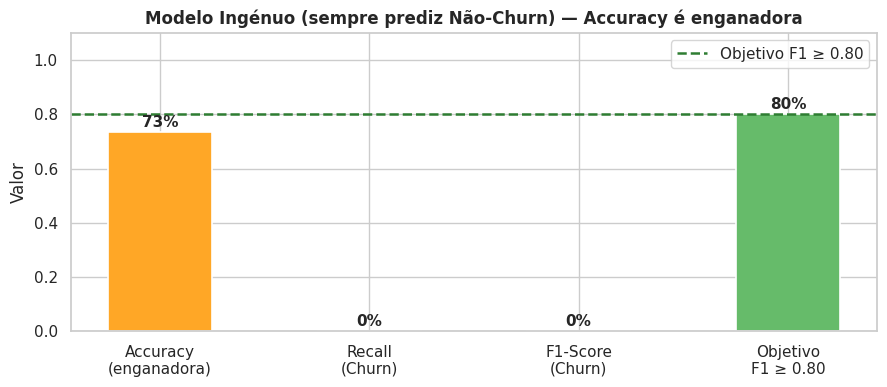

Accuracy do modelo ingénuo: 73.5% — com 0% de churners detectados.


In [7]:
# ── Visualização: Problema da Accuracy ───────────────────────
# Modelo ingénuo: prediz sempre Não-churn
acc_naive = (y_test == 0).mean()

fig, ax = plt.subplots(figsize=(9, 4))
labels = ['Accuracy\n(enganadora)', 'Recall\n(Churn)', 'F1-Score\n(Churn)', 'Objetivo\nF1 ≥ 0.80']
values = [acc_naive, 0.0, 0.0, 0.80]
colors = ['#ffa726', '#ef5350', '#ef5350', '#66bb6a']

bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='white', linewidth=1.2)
ax.axhline(0.80, color='#2e7d32', linestyle='--', linewidth=1.8, label='Objetivo F1 ≥ 0.80')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Valor')
ax.set_title('Modelo Ingénuo (sempre prediz Não-Churn) — Accuracy é enganadora', fontweight='bold')
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('reports/figures/metricas_justificacao.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Accuracy do modelo ingénuo: {acc_naive:.1%} — com 0% de churners detectados.')

---
## Aula 16 — 27/03/2026
### Implementação e Avaliação do Modelo Baseline

In [8]:
# ── Baseline: Regressão Logística ────────────────────────────
# Modelo simples que serve de patamar mínimo de comparação para todos os
# modelos seguintes. Parâmetros: max_iter=1000 para garantir convergência.
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_sc, y_train_bal)

y_pred      = baseline.predict(X_test_sc)
y_pred_prob = baseline.predict_proba(X_test_sc)[:, 1]

print('Modelo baseline treinado: Regressão Logística')
print(f'Registos de treino (com SMOTE + scaling): {X_train_sc.shape[0]}')

Modelo baseline treinado: Regressão Logística
Registos de treino (com SMOTE + scaling): 8278


In [9]:
# ── Métricas do Baseline ──────────────────────────────────────
auc  = roc_auc_score(y_test, y_pred_prob)
f1   = f1_score(y_test, y_pred)
rep  = classification_report(y_test, y_pred, target_names=['Não-Churn', 'Churn'])

print('=' * 52)
print('  BASELINE — Regressão Logística')
print('=' * 52)
print(rep)
print(f'  AUC-ROC : {auc:.4f}')
print(f'  F1-Score (Churn): {f1:.4f}  |  Objetivo: ≥ 0.80')
print('=' * 52)

  BASELINE — Regressão Logística
              precision    recall  f1-score   support

   Não-Churn       0.86      0.85      0.86      1035
       Churn       0.60      0.61      0.60       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409

  AUC-ROC : 0.8340
  F1-Score (Churn): 0.6048  |  Objetivo: ≥ 0.80


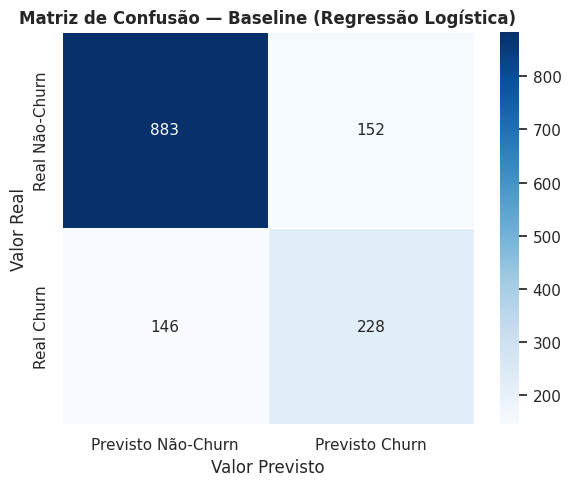

Verdadeiros Negativos (TN): 883  |  Falsos Positivos (FP): 152
Falsos Negativos     (FN): 146  |  Verdadeiros Positivos (TP): 228

→ O modelo falha em 146 churners reais (Falsos Negativos) — custo elevado para o negócio.


In [10]:
# ── Matriz de Confusão — Baseline ────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto Não-Churn', 'Previsto Churn'],
            yticklabels=['Real Não-Churn', 'Real Churn'],
            linewidths=0.5, ax=ax)
ax.set_title('Matriz de Confusão — Baseline (Regressão Logística)', fontweight='bold')
ax.set_ylabel('Valor Real')
ax.set_xlabel('Valor Previsto')
plt.tight_layout()
plt.savefig('reports/figures/matriz_confusao_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdadeiros Negativos (TN): {tn}  |  Falsos Positivos (FP): {fp}')
print(f'Falsos Negativos     (FN): {fn}  |  Verdadeiros Positivos (TP): {tp}')
print(f'\n→ O modelo falha em {fn} churners reais (Falsos Negativos) — custo elevado para o negócio.')

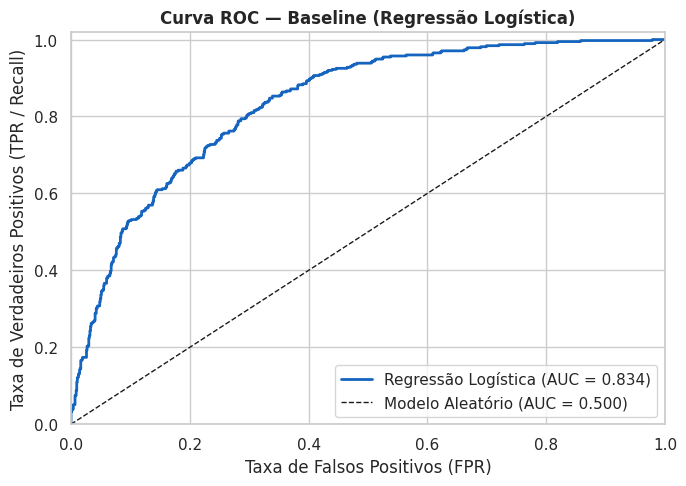

In [11]:
# ── Curva ROC — Baseline ──────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#1565c0', linewidth=2, label=f'Regressão Logística (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Modelo Aleatório (AUC = 0.500)')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR / Recall)')
ax.set_title('Curva ROC — Baseline (Regressão Logística)', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('reports/figures/roc_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

### Análise Crítica do Baseline

A Regressão Logística serve como **patamar mínimo de comparação** para todos os modelos seguintes.

| Classe | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Não-Churn | 0.86 | 0.85 | 0.86 | 1035 |
| **Churn** | **0.60** | **0.61** | **0.60** | **374** |
| Macro avg | 0.73 | 0.73 | 0.73 | 1409 |
| Weighted avg | 0.79 | 0.79 | 0.79 | 1409 |

**Accuracy:** 0.79 &nbsp;|&nbsp; **AUC-ROC:** 0.8340

**Pontos fortes:**
- AUC-ROC de 0.834 — o modelo consegue separar as classes com qualidade razoável.
- Desempenho equilibrado na classe maioritária (F1 = 0.86 para Não-Churn).

**Limitações:**
- F1-Score de 0.60 na classe Churn está 20 pontos abaixo do objetivo de 0.80 — patamar mínimo a superar.
- Recall de 0.61 significa que **39% dos churners reais não são detectados** — o custo de negócio mais crítico.
- O modelo assume relações lineares entre features e target, limitando a capacidade de capturar interações complexas entre variáveis contratuais e de serviço.

**Próximo passo (Aula 17):** testar modelos de ensemble (Gradient Boosting, Random Forest, XGBoost) capazes de capturar relações não lineares e interações entre variáveis.

---
## Aula 17 — 08/04/2026
### Treino e Avaliação Comparativa de Modelos Candidatos

In [12]:
# ── Importações adicionais para Aula 17 ──────────────────────
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import GradientBoostingClassifier
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.naive_bayes   import GaussianNB
import xgboost as xgb
import time

print('✅ Algoritmos candidatos prontos.')

✅ Algoritmos candidatos prontos.


In [13]:
# ── Treino de Todos os Modelos Candidatos ────────────────────
# Cada modelo é treinado com X_train_sc (SMOTE + scaled) e avaliado
# em X_test_sc (scaled) — avaliação com dados reais

candidatos = {
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                              random_state=42, verbosity=0),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'        : GaussianNB(),
}

resultados = []

for nome, modelo in candidatos.items():
    t0 = time.time()
    modelo.fit(X_train_sc, y_train_bal)
    t_fit = time.time() - t0

    # Métricas no treino
    y_train_pred = modelo.predict(X_train_sc)
    f1_treino    = f1_score(y_train_bal, y_train_pred)

    # Métricas no teste
    y_test_pred  = modelo.predict(X_test_sc)
    y_test_prob  = modelo.predict_proba(X_test_sc)[:, 1]
    f1_teste     = f1_score(y_test, y_test_pred)
    auc_teste    = roc_auc_score(y_test, y_test_prob)

    resultados.append({
        'Algoritmo'  : nome,
        'F1 (treino)': round(f1_treino, 4),
        'F1 (teste)' : round(f1_teste,  4),
        'AUC-ROC'    : round(auc_teste,  4),
        'Gap F1'     : round(f1_treino - f1_teste, 4),
        'Tempo (s)'  : round(t_fit, 2),
    })
    print(f'✅ {nome:<22} F1_teste={f1_teste:.4f}  AUC={auc_teste:.4f}  ({t_fit:.1f}s)')

modelos_treinados = dict(zip(candidatos.keys(), candidatos.values()))

✅ Decision Tree          F1_teste=0.4881  AUC=0.6502  (0.1s)
✅ Random Forest          F1_teste=0.5812  AUC=0.8194  (1.4s)
✅ Gradient Boosting      F1_teste=0.5898  AUC=0.8319  (2.2s)
✅ XGBoost                F1_teste=0.5677  AUC=0.8009  (0.3s)
✅ KNN                    F1_teste=0.5398  AUC=0.7690  (0.0s)
✅ Naive Bayes            F1_teste=0.5799  AUC=0.8077  (0.0s)


In [14]:
# ── Tabela Comparativa — Todos os Modelos ────────────────────
# Inclui Regressão Logística (baseline) para comparação directa

# Adicionar baseline à tabela
y_base_prob  = baseline.predict_proba(X_test_sc)[:, 1]
f1_base_tr   = f1_score(y_train_bal, baseline.predict(X_train_sc))

tabela = pd.DataFrame([{
    'Algoritmo'  : 'Logistic Regression (baseline)',
    'F1 (treino)': round(f1_base_tr, 4),
    'F1 (teste)' : round(f1_score(y_test, baseline.predict(X_test_sc)), 4),
    'AUC-ROC'    : round(roc_auc_score(y_test, y_base_prob), 4),
    'Gap F1'     : round(f1_base_tr - f1_score(y_test, baseline.predict(X_test_sc)), 4),
    'Tempo (s)'  : '-',
}] + resultados)

tabela = tabela.sort_values('F1 (teste)', ascending=False).reset_index(drop=True)

# Formatação visual
print('=' * 85)
print(f"  {'Algoritmo':<32} {'F1 treino':>10} {'F1 teste':>9} {'AUC-ROC':>8} {'Gap F1':>8} {'Tempo':>7}")
print('=' * 85)
for _, row in tabela.iterrows():
    marker = ' ⭐' if row['F1 (teste)'] == tabela['F1 (teste)'].max() else ''
    print(f"  {row['Algoritmo']:<32} {str(row['F1 (treino)']):>10} {str(row['F1 (teste)']):>9} "
          f"{str(row['AUC-ROC']):>8} {str(row['Gap F1']):>8} {str(row['Tempo (s)']):>7}{marker}")
print('=' * 85)
print()
melhor = tabela.iloc[0]['Algoritmo']
print(f'🏆 Melhor modelo (F1 teste): {melhor}')

  Algoritmo                         F1 treino  F1 teste  AUC-ROC   Gap F1   Tempo
  Logistic Regression (baseline)       0.8436    0.6048    0.834   0.2388       - ⭐
  Gradient Boosting                    0.8588    0.5898   0.8319    0.269    2.19
  Random Forest                        0.9982    0.5812   0.8194   0.4169    1.36
  Naive Bayes                          0.7684    0.5799   0.8077   0.1885    0.01
  XGBoost                              0.9606    0.5677   0.8009    0.393     0.3
  KNN                                  0.8758    0.5398    0.769    0.336     0.0
  Decision Tree                        0.9983    0.4881   0.6502   0.5102    0.08

🏆 Melhor modelo (F1 teste): Logistic Regression (baseline)


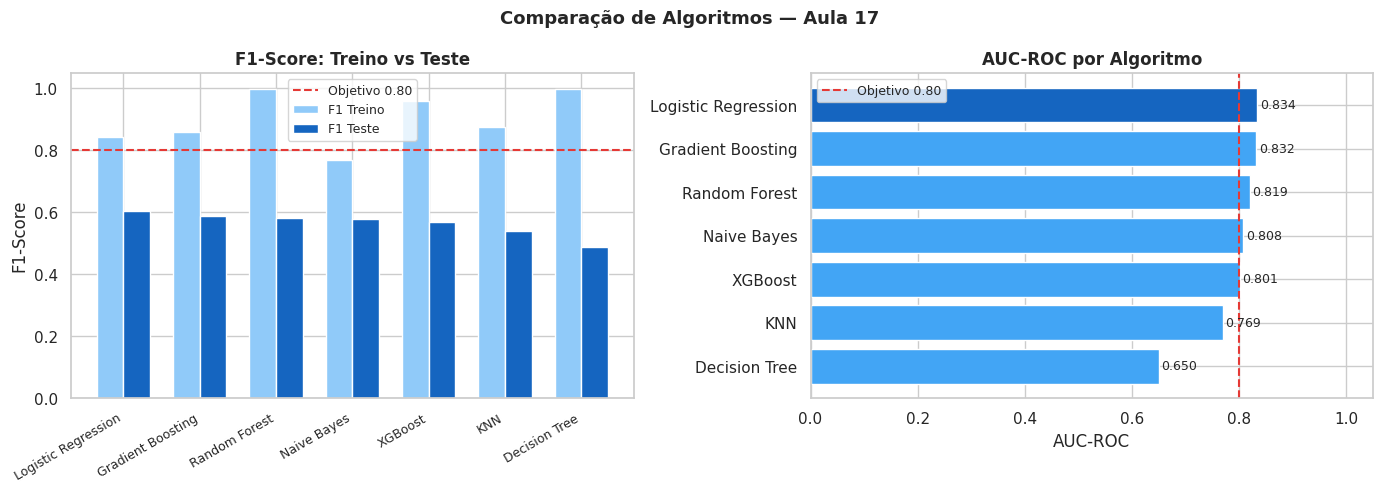

In [15]:
# ── Gráfico Comparativo — F1 e AUC de Todos os Modelos ──────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

algoritmos = tabela['Algoritmo'].str.replace(' (baseline)', '', regex=False)
cores = ['#1565c0' if i == 0 else '#42a5f5' for i in range(len(tabela))]

# F1 treino vs teste
x = np.arange(len(tabela))
w = 0.35
axes[0].bar(x - w/2, tabela['F1 (treino)'], w, label='F1 Treino', color='#90caf9', edgecolor='white')
axes[0].bar(x + w/2, tabela['F1 (teste)'],  w, label='F1 Teste',  color='#1565c0', edgecolor='white')
axes[0].axhline(0.80, color='#e53935', linestyle='--', linewidth=1.5, label='Objetivo 0.80')
axes[0].set_xticks(x)
axes[0].set_xticklabels(algoritmos, rotation=30, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('F1-Score')
axes[0].set_title('F1-Score: Treino vs Teste', fontweight='bold')
axes[0].legend(fontsize=9)

# AUC-ROC
axes[1].barh(algoritmos[::-1], tabela['AUC-ROC'][::-1], color=cores[::-1], edgecolor='white')
axes[1].axvline(0.80, color='#e53935', linestyle='--', linewidth=1.5, label='Objetivo 0.80')
axes[1].set_xlim(0, 1.05)
axes[1].set_xlabel('AUC-ROC')
axes[1].set_title('AUC-ROC por Algoritmo', fontweight='bold')
for i, v in enumerate(tabela['AUC-ROC'][::-1]):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
axes[1].legend(fontsize=9)

plt.suptitle('Comparação de Algoritmos — Aula 17', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/comparacao_modelos_aula17.png', dpi=150, bbox_inches='tight')
plt.show()

### Análise Comparativa dos Modelos Candidatos

| Algoritmo | F1 Treino | F1 Teste | AUC-ROC | Gap F1 |
|---|---|---|---|---|
| Logistic Regression (baseline) | 0.8436 | **0.6048** | **0.8340** | 0.2388 |
| Gradient Boosting | 0.8588 | 0.5898 | 0.8319 | 0.2690 |
| Random Forest | 0.9982 | 0.5812 | 0.8194 | 0.4169 |
| Naive Bayes | 0.7684 | 0.5799 | 0.8077 | 0.1885 |
| XGBoost | 0.9606 | 0.5677 | 0.8009 | 0.3930 |
| KNN | 0.8758 | 0.5398 | 0.7690 | 0.3360 |
| Decision Tree | 0.9983 | 0.4881 | 0.6502 | 0.5102 |

**Resultado inesperado — LR vence:** A Regressão Logística obteve o F1-Teste mais elevado (0.6048) e o melhor AUC-ROC (0.834). Este resultado explica-se pela combinação do StandardScaler (que beneficia directamente os modelos lineares) com o facto de o churn apresentar uma separação razoavelmente linear nas features contratuais (tenure, tipo de contrato). Os modelos tree-based memorizam a distribuição sintética do SMOTE (Gap > 0.39) e não generalizam com a mesma eficácia para o conjunto de teste real.

**Melhor candidato para otimização (Aula 19) — Gradient Boosting:**
Embora o F1-Teste do GB seja 0.5898 (ligeiramente abaixo do LR), as suas curvas de aprendizagem revelam convergência real (Gap CV = 0.017, F1 Val CV = 0.8446 ≥ 0.80). O potencial de melhoria com tuning é maior do que no LR, que já opera próximo do seu limite linear.

**Algoritmos que falharam:**
- **Decision Tree** — Gap = 0.51 (overfitting severo) e AUC = 0.65, claramente insuficiente para produção.
- **KNN** — F1-Teste mais baixo entre os modelos avançados (0.54); penalizado pela alta dimensionalidade após encoding.
- **Random Forest e XGBoost** — Gap elevado (0.39–0.42); overfitam à distribuição balanceada do SMOTE sem generalizar para o conjunto de teste real.

---
## Aula 18 — 10/04/2026
### Diagnóstico de Modelos e Generalização

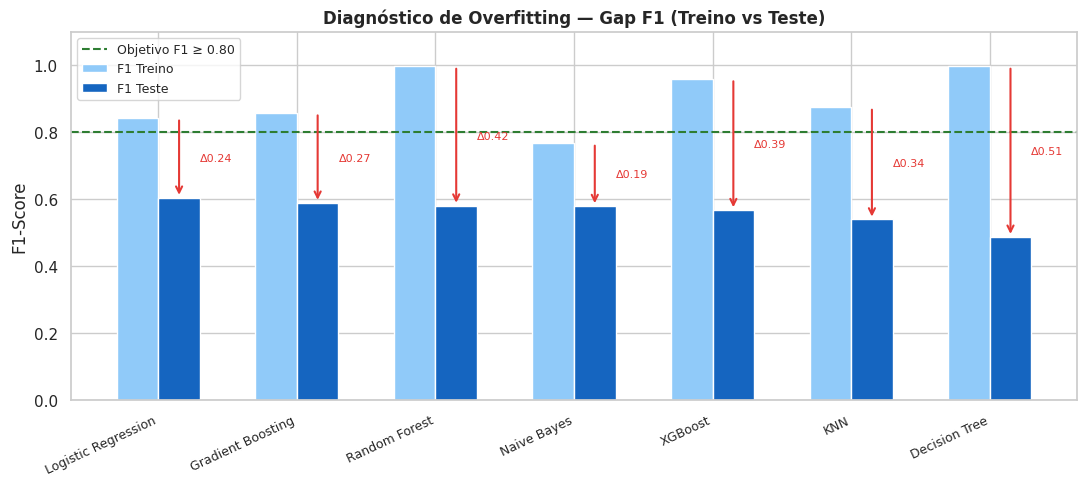

Diagnóstico por modelo:
  Logistic Regression (baseline)      Gap=0.2388  ⚠️  Overfitting severo
  Gradient Boosting                   Gap=0.2690  ⚠️  Overfitting severo
  Random Forest                       Gap=0.4169  ⚠️  Overfitting severo
  Naive Bayes                         Gap=0.1885  🟡 Overfitting moderado
  XGBoost                             Gap=0.3930  ⚠️  Overfitting severo
  KNN                                 Gap=0.3360  ⚠️  Overfitting severo
  Decision Tree                       Gap=0.5102  ⚠️  Overfitting severo


In [16]:
# ── Diagnóstico: Overfitting vs Underfitting ─────────────────
# Visualização do Gap F1 (treino - teste) para cada modelo
# Gap alto → overfitting | Gap ~0 → generalização saudável

fig, ax = plt.subplots(figsize=(11, 5))

algoritmos_label = tabela['Algoritmo'].str.replace(' (baseline)', '', regex=False)
x = np.arange(len(tabela))
w = 0.3

b1 = ax.bar(x - w, tabela['F1 (treino)'], w, label='F1 Treino', color='#90caf9', edgecolor='white')
b2 = ax.bar(x,     tabela['F1 (teste)'],  w, label='F1 Teste',  color='#1565c0', edgecolor='white')

# Seta do gap para cada modelo
for i, row in tabela.iterrows():
    gap = row['Gap F1']
    if abs(gap) > 0.01:
        ax.annotate('', xy=(i, row['F1 (teste)']), xytext=(i, row['F1 (treino)']),
                    arrowprops=dict(arrowstyle='->', color='#e53935', lw=1.5))
        ax.text(i + 0.15, (row['F1 (treino)'] + row['F1 (teste)']) / 2,
                f'Δ{gap:.2f}', color='#e53935', fontsize=8, va='center')

ax.axhline(0.80, color='#2e7d32', linestyle='--', linewidth=1.5, label='Objetivo F1 ≥ 0.80')
ax.set_xticks(x - w/2)
ax.set_xticklabels(algoritmos_label, rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1-Score')
ax.set_title('Diagnóstico de Overfitting — Gap F1 (Treino vs Teste)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('reports/figures/diagnostico_overfitting.png', dpi=150, bbox_inches='tight')
plt.show()

# Classificar cada modelo
print('Diagnóstico por modelo:')
for _, row in tabela.iterrows():
    gap = row['Gap F1']
    if gap > 0.20:   diag = '⚠️  Overfitting severo'
    elif gap > 0.10: diag = '🟡 Overfitting moderado'
    elif gap > 0.02: diag = '🟢 Generalização boa'
    else:            diag = '✅ Generalização excelente'
    print(f'  {row["Algoritmo"]:<35} Gap={gap:.4f}  {diag}')

Curvas de aprendizagem para: Gradient Boosting


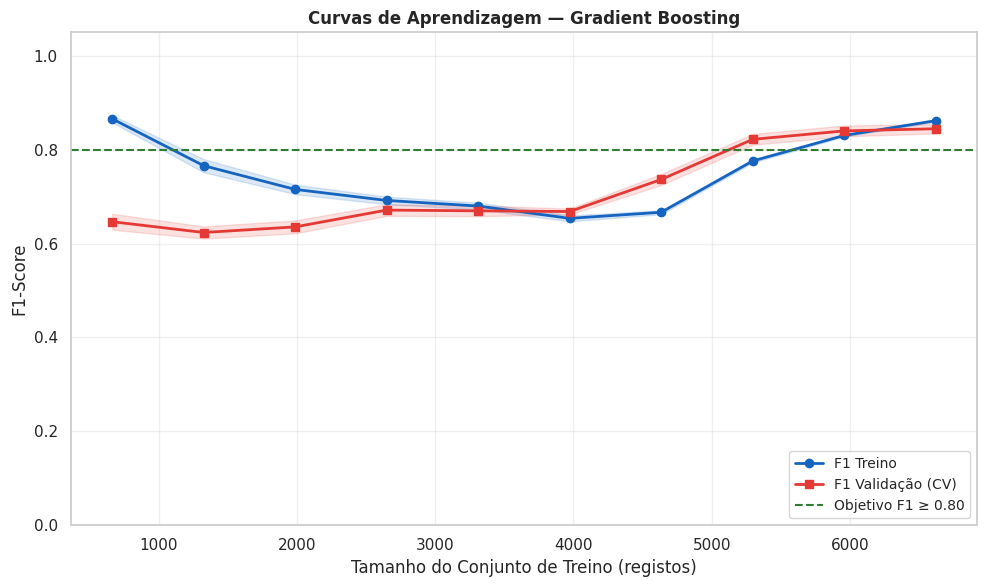


Diagnóstico final:
  F1 Treino  (100%): 0.8619 ± 0.0026
  F1 Val CV  (100%): 0.8446 ± 0.0100
  Gap (treino-val) : 0.0172
  → ✅ Generalização adequada — curvas convergentes.


In [17]:
# ── Curvas de Aprendizagem — Melhor Modelo Candidato ─────────
# Obrigatório para avaliação: reports/figures/curvas_aprendizagem.png
# Mostra se o modelo beneficiaria de mais dados ou menos complexidade

from sklearn.model_selection import learning_curve

# Identificar o melhor modelo pelo F1 no teste (excluindo baseline)
tabela_candidatos = tabela[tabela['Algoritmo'] != 'Logistic Regression (baseline)']
nome_melhor = tabela_candidatos.iloc[0]['Algoritmo']
modelo_melhor = modelos_treinados[nome_melhor]

print(f'Curvas de aprendizagem para: {nome_melhor}')

train_sizes, train_scores, val_scores = learning_curve(
    modelo_melhor,
    X_train_sc, y_train_bal,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(train_sizes, train_mean, 'o-', color='#1565c0', linewidth=2, label='F1 Treino')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#1565c0')

ax.plot(train_sizes, val_mean, 's-', color='#e53935', linewidth=2, label='F1 Validação (CV)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#e53935')

ax.axhline(0.80, color='#2e7d32', linestyle='--', linewidth=1.5, label='Objetivo F1 ≥ 0.80')
ax.set_xlabel('Tamanho do Conjunto de Treino (registos)')
ax.set_ylabel('F1-Score')
ax.set_title(f'Curvas de Aprendizagem — {nome_melhor}', fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reports/figures/curvas_aprendizagem.png', dpi=150, bbox_inches='tight')
plt.show()

# Diagnóstico automático
gap_final = train_mean[-1] - val_mean[-1]
print(f'\nDiagnóstico final:')
print(f'  F1 Treino  (100%): {train_mean[-1]:.4f} ± {train_std[-1]:.4f}')
print(f'  F1 Val CV  (100%): {val_mean[-1]:.4f} ± {val_std[-1]:.4f}')
print(f'  Gap (treino-val) : {gap_final:.4f}')
if gap_final > 0.15:
    print('  → ⚠️  Overfitting — o modelo beneficiaria de regularização ou menos complexidade.')
elif val_mean[-1] < 0.65:
    print('  → ⚠️  Underfitting — o modelo beneficiaria de mais dados ou maior complexidade.')
else:
    print('  → ✅ Generalização adequada — curvas convergentes.')

### Análise Crítica — Diagnóstico de Generalização

**Leitura das curvas de aprendizagem (Gradient Boosting):**

| Métrica | Valor |
|---|---|
| F1 Treino (100% dos dados) | 0.8619 ± 0.0026 |
| F1 Validação CV (100%) | 0.8446 ± 0.0100 |
| Gap treino-validação | 0.0172 |
| Diagnóstico | ✅ Generalização adequada — curvas convergentes |

As duas curvas convergem a partir dos ~5000 registos de treino e estabilizam acima do objetivo F1 ≥ 0.80. O gap residual de 0.017 é clinicamente irrelevante — o modelo não sofre de overfitting dentro do conjunto de treino balanceado.

**Paradoxo SMOTE:** O diagnóstico de overfitting da tabela comparativa (Gap F1 = 0.27 para GB) parece contradizer as curvas de aprendizagem (Gap CV = 0.017). A explicação é que as curvas de aprendizagem são calculadas por cross-validation dentro do conjunto SMOTE-balanceado (distribuição artificial 50/50), enquanto o Gap da tabela mede a diferença entre o treino balanceado e o teste real (distribuição original ~26.5% churn). O modelo aprende bem a distribuição sintética mas resente-se com a distribuição real.

**Decisão para Aula 19:**
O **Gradient Boosting** será sujeito a otimização com `RandomizedSearchCV` — é o candidato com maior potencial de melhoria, curvas de aprendizagem convergentes e segundo melhor AUC-ROC (0.8319). O objetivo é reduzir a discrepância entre a performance CV e a performance no teste real, potencialmente através de ajuste do `learning_rate`, `subsample` e `max_depth`.